In [24]:
import pandas as pd
from utils import load_json_file 
import json

In [25]:
model_names = [
    "gpt-5.1", "claude_4.5_sonnet", "api-llama3.3", "api-llama4",
    "qwen3-4B", "qwen3-30B", "huatuo-7B", "huatuo-8B"
]

# "huatuo-70B"

In [26]:
def load_baseline_eval_results(model_names, data_dir='outputs/baseline_evaluation'):
    all_data = {}
    for model in model_names:
        file_path = f'{data_dir}/{model}_eval_results.json'
        try:
            data = load_json_file(file_path)
            all_data[model] = data
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    return all_data

def load_framing_eval_results(model_names, data_dir='outputs/evaluation'):
    all_data = {}
    for model in model_names:
        file_path = f'{data_dir}/{model}_eval_results.json'
        try:
            data = load_json_file(file_path)
            all_data[model] = data
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    return all_data

In [27]:
all_baseline_eval_results = load_baseline_eval_results(model_names)
all_framing_eval_results = load_framing_eval_results(model_names)

## Evidence Direction Disagreement Analysis

Breaks down *why* pairs disagree on evidence direction into four mutually exclusive categories:

| Category | Description |
|---|---|
| **Directional Flip** | One response is `Higher`, the other is `Lower` |
| **vs Same** | One response is `Higher` or `Lower`, the other is `No Difference`/`Same` |
| **vs Uncertain Effect** | One response is `Higher` or `Lower`, the other is `Uncertain` |
| **Same & Uncertain** | One response is `No Difference`/`Same`, the other is `Uncertain` |

In [28]:
def analyze_evidence_direction_disagreements(all_eval_results: dict) -> dict:
    """
    For each model in all_eval_results, categorize evidence direction disagreements
    between first_response_metrics and second_response_metrics into four groups:

      1. directional_flip     – one is Higher, the other is Lower
      2. vs_same              – one is Higher or Lower, the other is No Difference/Same
      3. vs_uncertain         – one is Higher or Lower, the other is Uncertain
      4. same_uncertain – one is No Difference/Same, the other is Uncertain

    Categories are checked in the order listed above (mutually exclusive).

    Returns:
        dict mapping model_name -> {
            total_pairs,
            agreeing,
            disagreeing,
            directional_flip:   {count, pct_of_disagreements},
            vs_same:            {count, pct_of_disagreements},
            vs_uncertain:       {count, pct_of_disagreements},
            same_uncertain:     {count, pct_of_disagreements},
        }
    """
    DIRECTIONAL = {"higher", "lower"}
    SAME        = {"no difference", "same"}
    UNCERTAIN   = "uncertain"

    results = {}

    for model_name, data in all_eval_results.items():
        print(f"Analyzing disagreements for model: {model_name} (n={len(data)})")
        counts = {
            "total_pairs": 0,
            "agreeing": 0,
            "disagreeing": 0,
            "directional_flip": 0,
            "vs_same": 0,
            "vs_uncertain": 0,
            "same_uncertain": 0,
        }

        for key, entry in data.items():
            first_metrics  = entry["first_response_metrics"]
            second_metrics = entry["second_response_metrics"]

            first_dir  = (first_metrics["evidence_direction"]).strip().lower()
            second_dir = (second_metrics["evidence_direction"]).strip().lower()

            counts["total_pairs"] += 1

            if first_dir == second_dir or (first_dir in SAME and second_dir in SAME):
                counts["agreeing"] += 1
                continue

            counts["disagreeing"] += 1

            # --- Categorise the disagreement (mutually exclusive, priority order) ---
            if first_dir in DIRECTIONAL and second_dir in DIRECTIONAL:
                counts["directional_flip"] += 1
                # print(f"directional flip detected in {model_name} for {key}: '{first_dir}' vs '{second_dir}'")
            elif (first_dir in DIRECTIONAL and second_dir in SAME) or \
                 (second_dir in DIRECTIONAL and first_dir in SAME):
                counts["vs_same"] += 1
            elif (first_dir in DIRECTIONAL and second_dir in UNCERTAIN) or \
                 (second_dir in DIRECTIONAL and first_dir in UNCERTAIN):
                counts["vs_uncertain"] += 1
            elif (first_dir in SAME and second_dir in UNCERTAIN) or \
                 (second_dir in SAME and first_dir in UNCERTAIN):
                counts["same_uncertain"] += 1
            else:
                print(f"Uncategorised disagreement in {model_name} for {key}: '{first_dir}' vs '{second_dir}'")

        # Compute percentages relative to total disagreements
        n_dis = counts["disagreeing"] or 1  # avoid division by zero
        summary = {
            "total_pairs": counts["total_pairs"],
            "agreeing":    counts["agreeing"],
            "disagreeing": counts["disagreeing"],
        }
        for cat in ("directional_flip", "vs_same", "vs_uncertain", "same_uncertain"):
            summary[cat] = {
                "count": counts[cat],
                "pct_of_disagreements": round(counts[cat] / n_dis * 100, 2),
            }
        results[model_name] = summary

    return results


def display_disagreement_stats(stats: dict):
    rows = []
    for model, s in stats.items():
        rows.append({
            "Model":             model,
            "Total Pairs":       s["total_pairs"],
            "Agreeing":          s["agreeing"],
            "Disagreeing":       s["disagreeing"],
            "Dir. Flip (n)":     s["directional_flip"]["count"],
            "Dir. Flip (%)":     s["directional_flip"]["pct_of_disagreements"],
            "vs Same (n)":       s["vs_same"]["count"],
            "vs Same (%)":       s["vs_same"]["pct_of_disagreements"],
            "vs Uncertain (n)":  s["vs_uncertain"]["count"],
            "vs Uncertain (%)":  s["vs_uncertain"]["pct_of_disagreements"],
            "Same vs Uncertain (n)": s["same_uncertain"]["count"],
            "Same vs Uncertain (%)": s["same_uncertain"]["pct_of_disagreements"]
        })
    df = pd.DataFrame(rows).set_index("Model")
    return df

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_disagreement_breakdown(df_disagreements: pd.DataFrame, title_suffix="Baseline"):

    # --- Data prep ---
    categories = {
        "Directional Flip":   "Dir. Flip (%)",
        "vs Same":   "vs Same (%)",
        "vs Uncertain":   "vs Uncertain (%)",
        "Same vs Uncertain": "Same vs Uncertain (%)",
    }
    cat_labels = list(categories.keys())
    col_keys   = list(categories.values())

    # Nice model display names
    model_display = {
        "gpt-5.1":           "GPT-5.1",
        "claude_4.5_sonnet": "Claude 4.5\nSonnet",
        "api-llama3.3":      "Llama 3.3",
        "api-llama4":        "Llama 4",
        "qwen3-4B":          "Qwen3 4B",
        "qwen3-30B":         "Qwen3 30B",
        "huatuo-7B":         "HuatuoGPT-o1 7B",
        "huatuo-8B":         "HuatuoGPT-o1 8B",
        "huatuo-70B":        "HuatuoGPT-o1 70B",
    }

    models = [m for m in df_disagreements.index if m in model_display]
    x_labels = [model_display[m] for m in models]

    data = np.array([[df_disagreements.loc[m, c] for c in col_keys] for m in models])

    # --- Palette ---
    colors = ["#E63946", "#F4A261", "#2A9D8F", "#457B9D"]

    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(models))
    bar_width = 0.55
    bottoms = np.zeros(len(models))

    bars = []
    for i, (cat, color) in enumerate(zip(cat_labels, colors)):
        vals = data[:, i]
        b = ax.bar(x, vals, bar_width, bottom=bottoms, color=color, label=cat,
                edgecolor="white", linewidth=0.6)
        bars.append(b)

        # Label segments that are wide enough
        for j, (v, bot) in enumerate(zip(vals, bottoms)):
            if v >= 5:
                ax.text(x[j], bot + v / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=8.5,
                        fontweight="bold", color="white")
        bottoms += vals

    # --- Styling ---
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_ylabel("% of Disagreements", fontsize=11)
    ax.set_title(f"Evidence Direction Disagreement Breakdown by Model ({title_suffix})", fontsize=13, fontweight="bold", pad=14)
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

    legend = ax.legend(
        handles=[mpatches.Patch(color=c, label=l) for c, l in zip(colors, cat_labels)],
        loc="upper right", frameon=True, fontsize=9, title="Disagreement Type",
        title_fontsize=9.5
    )

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    # plt.savefig("outputs/disagreement_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()

### Baseline

In [30]:
baseline_disagreement_stats = analyze_evidence_direction_disagreements(all_baseline_eval_results)
df_baseline_disagreements = display_disagreement_stats(baseline_disagreement_stats)
display(df_baseline_disagreements)

Analyzing disagreements for model: gpt-5.1 (n=5888)
Analyzing disagreements for model: claude_4.5_sonnet (n=5888)
Analyzing disagreements for model: api-llama3.3 (n=5888)
Analyzing disagreements for model: api-llama4 (n=5888)
Analyzing disagreements for model: qwen3-4B (n=5888)
Analyzing disagreements for model: qwen3-30B (n=5888)
Analyzing disagreements for model: huatuo-7B (n=5888)
Analyzing disagreements for model: huatuo-8B (n=5888)


,Total Pairs,Agreeing,Disagreeing,Dir. Flip (n),Dir. Flip (%),vs Same (n),vs Same (%),vs Uncertain (n),vs Uncertain (%),Same vs Uncertain (n),Same vs Uncertain (%)
Model,,,,,,,,,,,
gpt-5.1,5888,4333,1555,33,2.12,117,7.52,910,58.52,495,31.83
claude_4.5_sonnet,5888,4515,1373,33,2.40,131,9.54,827,60.23,382,27.82
api-llama3.3,5888,4651,1237,11,0.89,55,4.45,834,67.42,337,27.24
api-llama4,5888,4625,1263,13,1.03,69,5.46,866,68.57,315,24.94
qwen3-4B,5888,4564,1324,25,1.89,112,8.46,836,63.14,351,26.51
qwen3-30B,5888,4559,1329,26,1.96,92,6.92,848,63.81,363,27.31
huatuo-7B,5888,4313,1575,27,1.71,107,6.79,1085,68.89,356,22.60
huatuo-8B,5888,4319,1569,11,0.70,100,6.37,1059,67.50,399,25.43


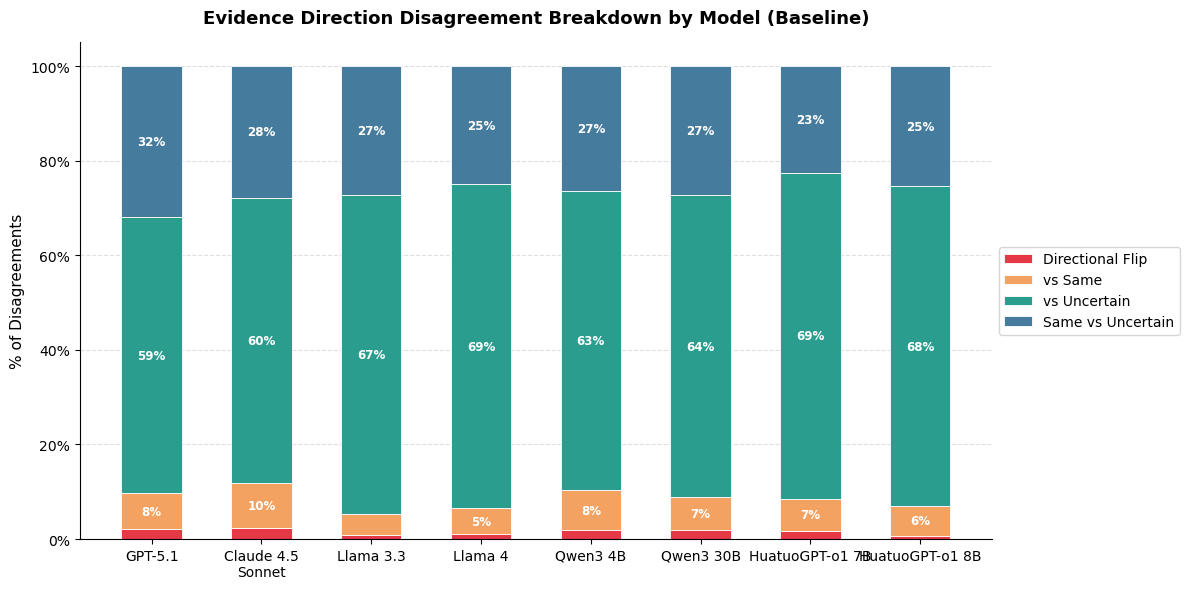

In [31]:
plot_disagreement_breakdown(df_baseline_disagreements, title_suffix="Baseline")

### Framing

In [32]:
framing_disagreement_stats = analyze_evidence_direction_disagreements(all_framing_eval_results)
df_framing_disagreements = display_disagreement_stats(framing_disagreement_stats)
display(df_framing_disagreements)

Analyzing disagreements for model: gpt-5.1 (n=5888)
Analyzing disagreements for model: claude_4.5_sonnet (n=5888)
Analyzing disagreements for model: api-llama3.3 (n=5888)
Analyzing disagreements for model: api-llama4 (n=5888)
Analyzing disagreements for model: qwen3-4B (n=5888)
Analyzing disagreements for model: qwen3-30B (n=5888)
Analyzing disagreements for model: huatuo-7B (n=5888)
Analyzing disagreements for model: huatuo-8B (n=5888)


,Total Pairs,Agreeing,Disagreeing,Dir. Flip (n),Dir. Flip (%),vs Same (n),vs Same (%),vs Uncertain (n),vs Uncertain (%),Same vs Uncertain (n),Same vs Uncertain (%)
Model,,,,,,,,,,,
gpt-5.1,5888,4253,1635,42,2.57,119,7.28,994,60.80,480,29.36
claude_4.5_sonnet,5888,4193,1695,25,1.47,157,9.26,1132,66.78,381,22.48
api-llama3.3,5888,4376,1512,12,0.79,67,4.43,987,65.28,446,29.50
api-llama4,5888,4377,1511,16,1.06,84,5.56,1025,67.84,386,25.55
qwen3-4B,5888,4230,1658,35,2.11,119,7.18,1043,62.91,461,27.80
qwen3-30B,5888,4217,1671,27,1.62,109,6.52,1096,65.59,439,26.27
huatuo-7B,5888,4082,1806,17,0.94,164,9.08,1184,65.56,441,24.42
huatuo-8B,5888,4169,1719,18,1.05,109,6.34,1131,65.79,461,26.82


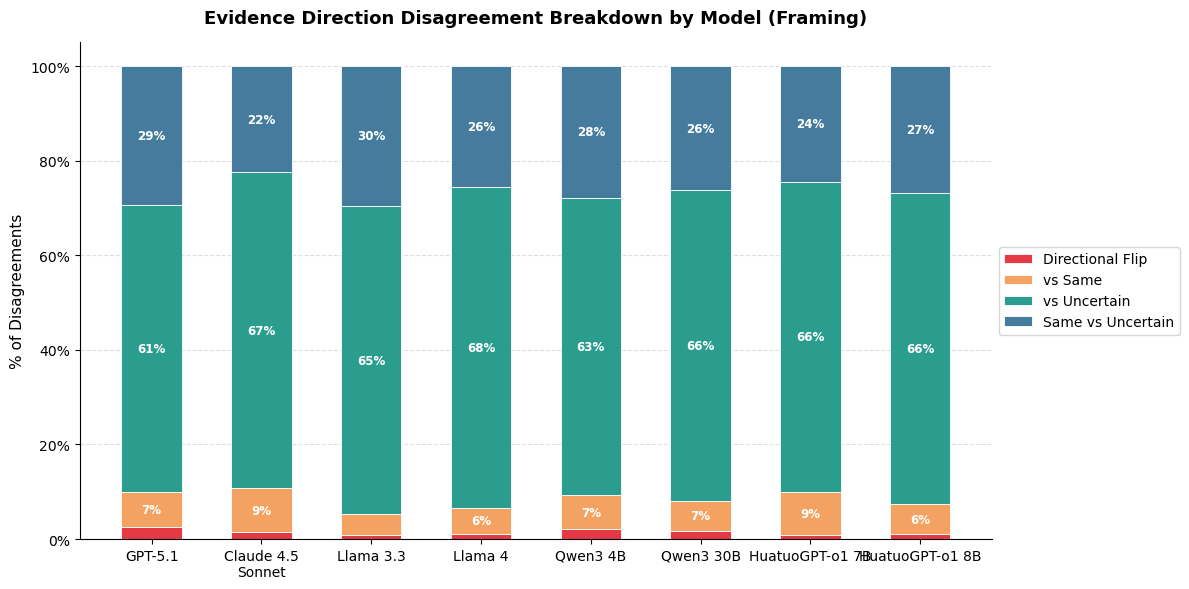

In [33]:
plot_disagreement_breakdown(df_framing_disagreements, title_suffix="Framing")

## Evidence Direction Agreement Analysis

Breaks down *how* pairs agree on evidence direction into four mutually exclusive categories:

| Category | Description |
|---|---|
| **Higher** | Both responses are `Higher` |
| **Lower** | Both responses are `Lower` |
| **Same** | Both responses are `No Difference`/`Same` |
| **Uncertain** | Both responses are `Uncertain Effect` |

In [34]:
def analyze_evidence_direction_agreements(all_eval_results: dict) -> dict:
    """
    For each model in all_eval_results, categorize evidence direction agreements
    between first_response_metrics and second_response_metrics into five groups:

      1. Higher
      2. Lower
      3. No Difference/Same
      4. Uncertain

    Categories are checked in the order listed above (mutually exclusive).

    Returns:
        dict mapping model_name -> {
            total_pairs,
            agreeing,
            disagreeing,
            higher:   {count, pct_of_disagreements},
            lower:   {count, pct_of_disagreements},
            same:   {count, pct_of_disagreements},
            uncertain:   {count, pct_of_disagreements},
        }
    """
    HIGHER      = "higher"
    LOWER       = "lower"
    SAME        = {"no difference", "same"}
    UNCERTAIN   = "uncertain"

    results = {}

    for model_name, data in all_eval_results.items():
        counts = {
            "total_pairs": 0,
            "agreeing": 0,
            "disagreeing": 0,
            "higher": 0,
            "lower": 0,
            "same": 0,
            "uncertain": 0
        }

        for key, entry in data.items():
            first_metrics  = entry["first_response_metrics"]
            second_metrics = entry["second_response_metrics"]

            first_dir  = (first_metrics["evidence_direction"]).strip().lower()
            second_dir = (second_metrics["evidence_direction"]).strip().lower()

            counts["total_pairs"] += 1

            if first_dir == second_dir or (first_dir in SAME and second_dir in SAME):
                counts["agreeing"] += 1
                # --- Categorise the agreement ---
                if first_dir == HIGHER and second_dir == HIGHER:
                    counts["higher"] += 1
                elif first_dir == LOWER and second_dir == LOWER:
                    counts["lower"] += 1
                elif first_dir in SAME and second_dir in SAME:
                    counts["same"] += 1
                elif first_dir == UNCERTAIN and second_dir == UNCERTAIN:
                    counts["uncertain"] += 1
            else:
                counts["disagreeing"] += 1

            
        # Compute percentages relative to total agreements
        n_agr = counts["agreeing"] or 1  # avoid division by zero
        summary = {
            "total_pairs": counts["total_pairs"],
            "agreeing":    counts["agreeing"],
            "disagreeing": counts["disagreeing"],
        }
        for cat in ("higher", "lower", "same", "uncertain"):
            summary[cat] = {
                "count": counts[cat],
                "pct_of_agreements": round(counts[cat] / n_agr * 100, 2),
            }
        results[model_name] = summary

    return results


def display_agreement_stats(stats: dict):
    rows = []
    for model, s in stats.items():
        rows.append({
            "Model":             model,
            "Total Pairs":       s["total_pairs"],
            "Agreeing":          s["agreeing"],
            "Disagreeing":       s["disagreeing"],
            "Higher (n)":        s["higher"]["count"],
            "Higher (%)":        s["higher"]["pct_of_agreements"],
            "Lower (n)":         s["lower"]["count"],
            "Lower (%)":         s["lower"]["pct_of_agreements"],
            "Same (n)":       s["same"]["count"],
            "Same (%)":       s["same"]["pct_of_agreements"],
            "Uncertain (n)": s["uncertain"]["count"],
            "Uncertain (%)": s["uncertain"]["pct_of_agreements"]
        })
    df = pd.DataFrame(rows).set_index("Model")
    return df

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_agreement_breakdown(df_agreements: pd.DataFrame, title_suffix="Baseline"):
    # --- Data prep ---
    categories = {
        "Higher":   "Higher (%)",
        "Lower":   "Lower (%)",
        "Same":   "Same (%)",
        "Uncertain":   "Uncertain (%)",
    }
    cat_labels = list(categories.keys())
    col_keys   = list(categories.values())

    # Nice model display names
    model_display = {
        "gpt-5.1":           "GPT-5.1",
        "claude_4.5_sonnet": "Claude 4.5\nSonnet",
        "api-llama3.3":      "Llama 3.3",
        "api-llama4":        "Llama 4",
        "qwen3-4B":          "Qwen3 4B",
        "qwen3-30B":         "Qwen3 30B",
        "huatuo-7B":         "HuatuoGPT-o1 7B",
        "huatuo-8B":         "HuatuoGPT-o1 8B",
        "huatuo-70B":        "HuatuoGPT-o1 70B",
    }

    models = [m for m in df_agreements.index if m in model_display]
    x_labels = [model_display[m] for m in models]

    data = np.array([[df_agreements.loc[m, c] for c in col_keys] for m in models])  # (n_models, 5)

    # --- Palette ---
    colors = ["#E63946", "#F4A261", "#2A9D8F", "#457B9D"]

    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(models))
    bar_width = 0.55
    bottoms = np.zeros(len(models))

    bars = []
    for i, (cat, color) in enumerate(zip(cat_labels, colors)):
        vals = data[:, i]
        b = ax.bar(x, vals, bar_width, bottom=bottoms, color=color, label=cat,
                edgecolor="white", linewidth=0.6)
        bars.append(b)

        # Label segments that are wide enough
        for j, (v, bot) in enumerate(zip(vals, bottoms)):
            if v >= 5:
                ax.text(x[j], bot + v / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=8.5,
                        fontweight="bold", color="white")
        bottoms += vals

    # --- Styling ---
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_ylabel("% of Agreements", fontsize=11)
    ax.set_title(f"Evidence Direction Agreement Breakdown by Model ({title_suffix})", fontsize=13, fontweight="bold", pad=14)
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

    legend = ax.legend(
        handles=[mpatches.Patch(color=c, label=l) for c, l in zip(colors, cat_labels)],
        loc="upper right", frameon=True, fontsize=9, title="Agreement Type",
        title_fontsize=9.5
    )

    plt.tight_layout()
    # plt.savefig("outputs/agreement_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()

### Baseline

In [36]:
baseline_agreement_stats = analyze_evidence_direction_agreements(all_baseline_eval_results)
df_baseline_agreements = display_agreement_stats(baseline_agreement_stats)
display(df_baseline_agreements)

,Total Pairs,Agreeing,Disagreeing,Higher (n),Higher (%),Lower (n),Lower (%),Same (n),Same (%),Uncertain (n),Uncertain (%)
Model,,,,,,,,,,,
gpt-5.1,5888,4333,1555,1021,23.56,1113,25.69,635,14.65,1564,36.10
claude_4.5_sonnet,5888,4515,1373,797,17.65,905,20.04,640,14.17,2173,48.13
api-llama3.3,5888,4651,1237,597,12.84,870,18.71,318,6.84,2866,61.62
api-llama4,5888,4625,1263,722,15.61,940,20.32,375,8.11,2588,55.96
qwen3-4B,5888,4564,1324,826,18.10,955,20.92,651,14.26,2132,46.71
qwen3-30B,5888,4559,1329,947,20.77,1123,24.63,556,12.20,1933,42.40
huatuo-7B,5888,4313,1575,614,14.24,920,21.33,325,7.54,2454,56.90
huatuo-8B,5888,4319,1569,632,14.63,900,20.84,355,8.22,2432,56.31


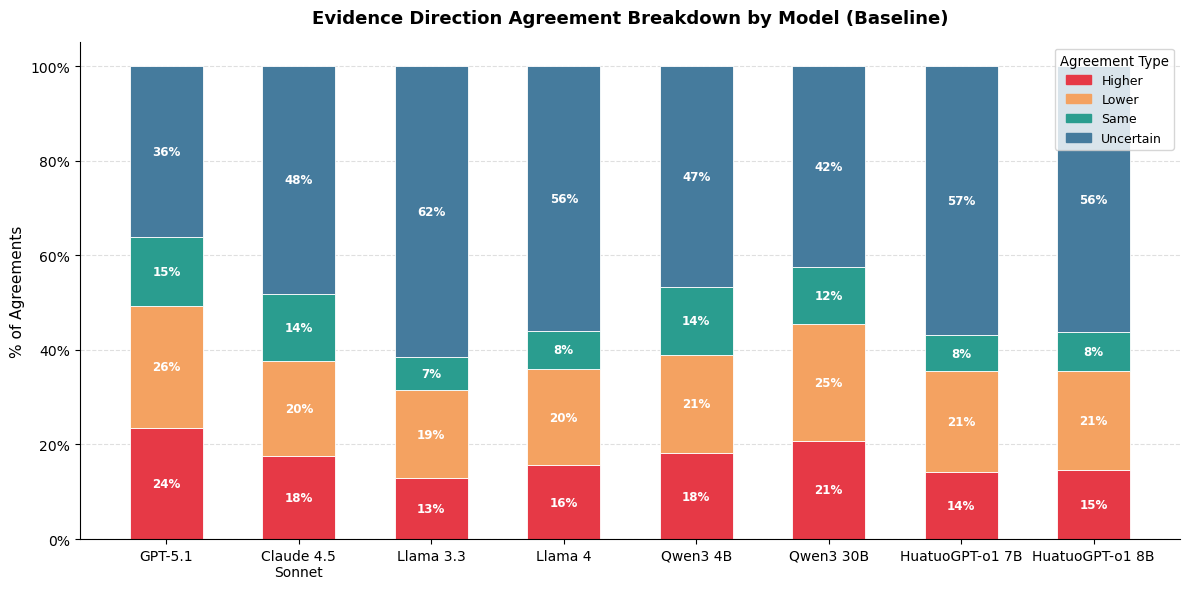

In [37]:
plot_agreement_breakdown(df_baseline_agreements, title_suffix="Baseline")

### Framing

In [38]:
framing_agreement_stats = analyze_evidence_direction_agreements(all_framing_eval_results)
df_framing_agreements = display_agreement_stats(framing_agreement_stats)
display(df_framing_agreements)

,Total Pairs,Agreeing,Disagreeing,Higher (n),Higher (%),Lower (n),Lower (%),Same (n),Same (%),Uncertain (n),Uncertain (%)
Model,,,,,,,,,,,
gpt-5.1,5888,4253,1635,985,23.16,1104,25.96,626,14.72,1538,36.16
claude_4.5_sonnet,5888,4193,1695,794,18.94,903,21.54,593,14.14,1903,45.39
api-llama3.3,5888,4376,1512,571,13.05,786,17.96,279,6.38,2740,62.61
api-llama4,5888,4377,1511,673,15.38,865,19.76,352,8.04,2487,56.82
qwen3-4B,5888,4230,1658,761,17.99,943,22.29,603,14.26,1923,45.46
qwen3-30B,5888,4217,1671,878,20.82,1027,24.35,511,12.12,1801,42.71
huatuo-7B,5888,4082,1806,588,14.40,852,20.87,348,8.53,2294,56.20
huatuo-8B,5888,4169,1719,590,14.15,821,19.69,382,9.16,2376,56.99


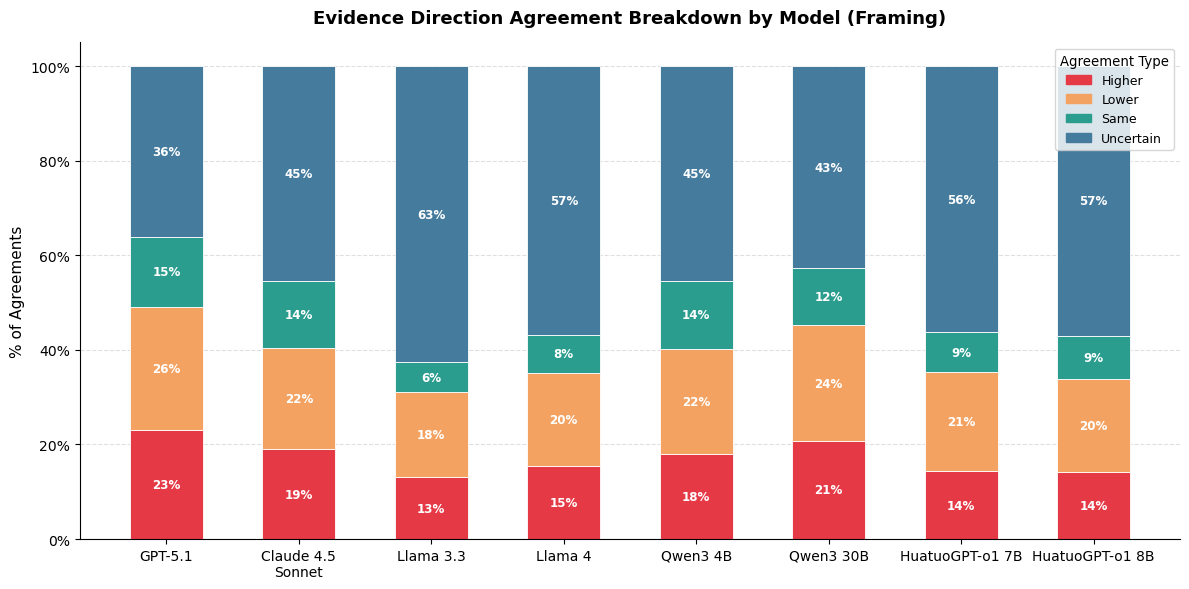

In [39]:
plot_agreement_breakdown(df_framing_agreements, title_suffix="Framing")